# Waypoint Constraints

This example constrains Amsterdam Schiphol (`EHAM`) to Rome Fiumicino (`LIRF`) through named fixes from OpenAP's packaged navigation database. The fixes intentionally create a one-sided convex detour away from the direct route, and the optimizer is constrained to pass within 2 km of each fix.


In [1]:
import warnings

import matplotlib.pyplot as plt
import openap
from cartopy import crs as ccrs
from cartopy.feature import BORDERS, LAND, OCEAN

import opentop as top

warnings.filterwarnings("ignore")

In [2]:
actype = "A320"
origin = "EHAM"
destination = "LIRF"
m0 = 0.85
fix_names = ("SIGEN", "FUSSE", "ROKIB")
waypoint_tolerance_m = 2_000

waypoints = []
for fix_name in fix_names:
    lat, lon, _ = openap.nav.fix(fix_name)
    waypoints.append((float(lat), float(lon)))

list(zip(fix_names, waypoints))

[('SIGEN', (50.846111, 8.279444)),
 ('FUSSE', (47.574289, 10.429847)),
 ('ROKIB', (45.935556, 11.692222))]

In [3]:
cruise_optimizer = top.Cruise(actype, origin, destination, m0)
cruise_optimizer.setup()
cruise_flight = cruise_optimizer.trajectory(
    objective="fuel",
    waypoints=waypoints,
    waypoint_tolerance_m=waypoint_tolerance_m,
)

complete_optimizer = top.CompleteFlight(actype, origin, destination, m0)
complete_optimizer.setup()
complete_flight = complete_optimizer.trajectory(
    objective="fuel",
    waypoints=waypoints,
    waypoint_tolerance_m=waypoint_tolerance_m,
)

In [4]:
def closest_distances(flight, waypoints):
    distances = []
    for waypoint in waypoints:
        fix_distances = [
            openap.aero.distance(lat, lon, waypoint[0], waypoint[1])
            for lat, lon in zip(flight.latitude, flight.longitude)
        ]
        distances.append(min(fix_distances))
    return distances


print("Route: " + origin + " -> " + " -> ".join(fix_names) + " -> " + destination)
for label, optimizer, flight in (
    ("Cruise", cruise_optimizer, cruise_flight),
    ("CompleteFlight", complete_optimizer, complete_flight),
):
    fuel_burn = flight.mass.iloc[0] - flight.mass.iloc[-1]
    elapsed_time = flight.ts.iloc[-1] / 60
    print(f"\n{label}")
    print(f"  success: {optimizer.success}")
    print(f"  fuel burn: {fuel_burn:.1f} kg")
    print(f"  elapsed time: {elapsed_time:.1f} min")
    for fix_name, distance in zip(fix_names, closest_distances(flight, waypoints)):
        print(f"  {fix_name}: closest trajectory point {distance / 1000:.1f} km")

Route: EHAM -> SIGEN -> FUSSE -> ROKIB -> LIRF

Cruise
  success: True
  fuel burn: 4384.4 kg
  elapsed time: 97.2 min
  SIGEN: closest trajectory point 2.0 km
  FUSSE: closest trajectory point 2.0 km
  ROKIB: closest trajectory point 2.0 km

CompleteFlight
  success: True
  fuel burn: 4800.6 kg
  elapsed time: 108.3 min
  SIGEN: closest trajectory point 2.0 km
  FUSSE: closest trajectory point 2.0 km
  ROKIB: closest trajectory point 2.0 km


In [5]:
origin_info = openap.nav.airport(origin)
destination_info = openap.nav.airport(destination)
airport_points = [
    (origin, float(origin_info["lat"]), float(origin_info["lon"])),
    (destination, float(destination_info["lat"]), float(destination_info["lon"])),
]

all_lons = [*cruise_flight.longitude, *complete_flight.longitude]
all_lats = [*cruise_flight.latitude, *complete_flight.latitude]
all_lons.extend(lon for _, lon in waypoints)
all_lats.extend(lat for lat, _ in waypoints)
all_lons.extend(lon for _, _, lon in airport_points)
all_lats.extend(lat for _, lat, _ in airport_points)
map_extent = [
    min(all_lons) - 1.0,
    max(all_lons) + 1.0,
    min(all_lats) - 0.8,
    max(all_lats) + 0.8,
]


def plot_route_map(flight, title, color):
    projection = ccrs.TransverseMercator(
        central_longitude=9,
        central_latitude=47,
    )
    _fig, ax = plt.subplots(
        figsize=(8, 7),
        subplot_kw={"projection": projection},
    )
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.add_feature(LAND, facecolor="#f3f0e8", edgecolor="none")
    ax.add_feature(OCEAN, facecolor="#d9ecf2", edgecolor="none")
    ax.add_feature(BORDERS, lw=0.5, color="0.45")
    ax.coastlines(resolution="50m", lw=0.5, color="0.45")
    ax.gridlines(draw_labels=True, color="0.6", alpha=0.5, ls="--")

    ax.plot(
        [airport_points[0][2], airport_points[1][2]],
        [airport_points[0][1], airport_points[1][1]],
        color="tab:gray",
        lw=1.0,
        ls="--",
        label="Direct airport line",
        transform=ccrs.PlateCarree(),
        zorder=1,
    )
    ax.plot(
        flight.longitude,
        flight.latitude,
        marker="o",
        color=color,
        lw=1.5,
        ms=4,
        label="Optimized trajectory",
        transform=ccrs.PlateCarree(),
        zorder=3,
    )
    ax.scatter(
        [lon for _, lon in waypoints],
        [lat for lat, _ in waypoints],
        marker="x",
        s=90,
        color="tab:red",
        label="Fixes",
        transform=ccrs.PlateCarree(),
        zorder=6,
    )
    ax.scatter(
        [lon for _, _, lon in airport_points],
        [lat for _, lat, _ in airport_points],
        marker="^",
        s=80,
        color="tab:gray",
        label="Airports",
        transform=ccrs.PlateCarree(),
        zorder=7,
    )

    for fix_name, (lat, lon) in zip(fix_names, waypoints):
        ax.text(
            lon + 0.08,
            lat + 0.05,
            fix_name,
            fontsize=9,
            transform=ccrs.PlateCarree(),
            zorder=8,
        )
    for airport, lat, lon in airport_points:
        ax.text(
            lon + 0.08,
            lat + 0.05,
            airport,
            fontsize=9,
            transform=ccrs.PlateCarree(),
            zorder=8,
        )

    ax.set_title(title)
    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

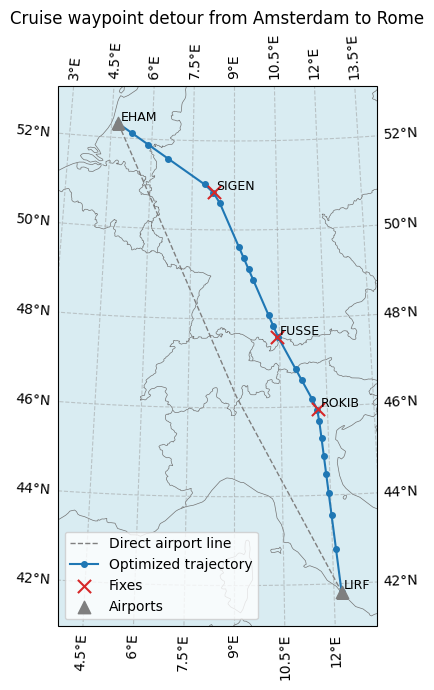

In [6]:
plot_route_map(
    cruise_flight,
    "Cruise waypoint detour from Amsterdam to Rome",
    "tab:blue",
)

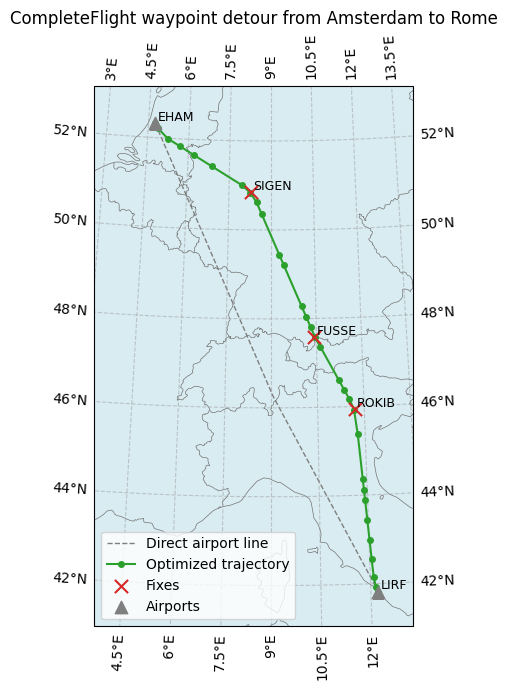

In [7]:
plot_route_map(
    complete_flight,
    "CompleteFlight waypoint detour from Amsterdam to Rome",
    "tab:green",
)

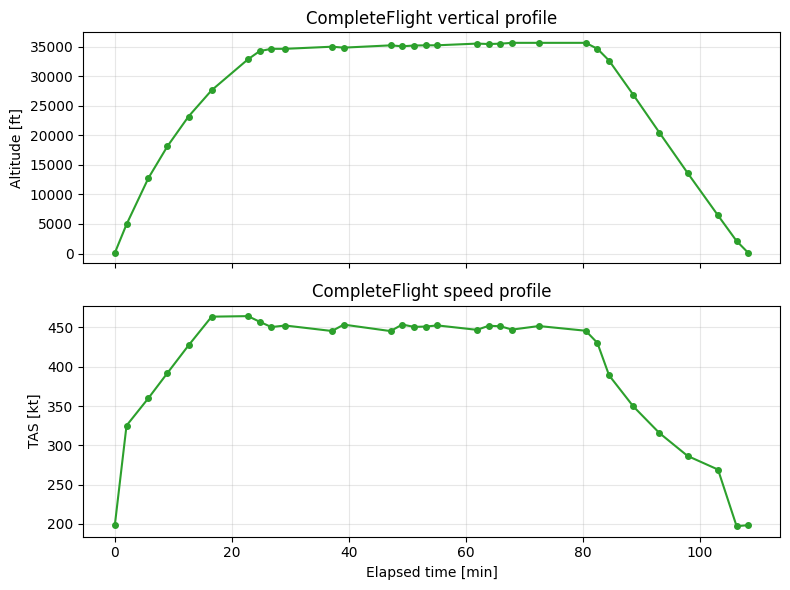

In [8]:
time_min = complete_flight.ts / 60

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(
    time_min,
    complete_flight.altitude,
    marker="o",
    ms=4,
    color="tab:green",
)
axes[0].set_ylabel("Altitude [ft]")
axes[0].set_title("CompleteFlight vertical profile")
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_min, complete_flight.tas, marker="o", ms=4, color="tab:green")
axes[1].set_xlabel("Elapsed time [min]")
axes[1].set_ylabel("TAS [kt]")
axes[1].set_title("CompleteFlight speed profile")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()